# 🩺 **Guardiã AI - Inteligência Artificial para Saúde e Segurança da Mulher**

Este notebook contém o código-fonte do "Guardiã AI - Inteligência Artificial para Saúde e Segurança da Mulher", solução desenvolvida no âmbito do desafio (Tech Challenge) apresentado durante a Quinta Fase da Pós Tech (8IADT), da Faculdade de Informática e Administração Paulista (FIAP), conforme requisitos contidos no PDF disponível no seguinte repositório: https://github.com/marceloklotz/fiap-quinta-fase

O desafio propõe a criação do Guardiã AI - Inteligência Artificial para Saúde e Segurança da Mulher, uma aplicação capaz de receber informações de um atendimento e utilizar Inteligência Artificial para auxiliar na análise inicial do caso, auxiliando às equipes profissionais atuantes em questões voltadas à saúde da mulher e à segurança da mulher.

⚠️ **Aviso de Responsabilidade (Disclaimer)**: Este projeto foi desenvolvido exclusivamente para fins educacionais. Ressaltamos que a ferramenta não substitui validações médicas e não está apta para embasar decisões clínicas, realizar diagnósticos, apoiar triagens ou auxiliar vítimas em situações de emergência. Toda e qualquer interpretação dos resultados deve ficar a cargo de profissionais competentes.


# 1. 🛠️ Instalação de Dependências

Este bloco instala todas as bibliotecas necessárias para rodar o pipeline completo do Guardiã AI. Ele inclui pacotes para transcrição de áudio (openai-whisper), processamento de sinais (librosa), Inteligência Artificial Generativa e RAG (langchain, faiss-cpu), geração de dados sintéticos (faker) e Machine Learning/Explicabilidade (xgboost, shap, scikit-learn).

In [1]:
!pip install openai-whisper librosa deep-translator transformers langchain-core langchain-openai langchain-community tiktoken faiss-cpu faker xgboost shap scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 6.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.4/127.4 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.1/572.1 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.7 MB/s eta 0:00:00
  Created wheel for openai-whisper: filename=openai_whisper-20250625-py3-none-

# 2. ⚙️ Importação de Bibliotecas e Configuração de Ambiente

Aqui carregamos os módulos essenciais e configuramos a chave de API da OpenAI de forma segura utilizando a biblioteca getpass, evitando que a credencial fique exposta no código.

In [2]:
import os
import getpass
import pandas as pd
import numpy as np
import random
import re
import glob
from datetime import datetime
import xgboost as xgb
import shap
import librosa
import whisper
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, f1_score, confusion_matrix
from deep_translator import GoogleTranslator
from langchain_core.prompts import PromptTemplate
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.callbacks import get_openai_callback
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuração da API Key
if "OPENAI_API_KEY" not in os.environ:
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Insira sua OpenAI API Key: ")

print("✅ Ambiente e ferramentas configurados com sucesso!")

/tmp/ipykernel_28790/1477332310.py:21: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.callbacks import get_openai_callback


Insira sua OpenAI API Key: ··········
✅ Ambiente e ferramentas configurados com sucesso!


# 2.5 📁 Montagem do Google Drive (RAG)
Célula dedicada a montar o sistema de arquivos do Google Drive no ambiente Colab, permitindo que a solução recupere os arquivos Markdown (.md) de protocolos PCDTs armazenados no drive do usuário.

**IMPORTANTE** O script que extrai todos os Protocolos Clínicos e Diretrizes Terapêuticas (PCDTs) contidos no portal do Ministério da Saúde (https://www.gov.br/saude/pt-br/assuntos/pcdt) foi disponibilizado em notebook separado no repositório desse projeto e pode ser baixado pelo seguinte endereço: https://github.com/marceloklotz/fiap-quinta-fase/blob/main/PCDTs.ipynb

O código realiza a compactação dos protocolos disponibilizados originalmente em PDF, exporta para ZIP, além de converter, enriquecer e transformar em arquivos tipo *markdown*. O notebook contém a implementação completa do RAG com a extração, carregamento dos documentos, possibilitando a recuperação dos trechos relevantes e a inserção desses trechos neste notebook.

Resumo do fluxo para etapas utilizadas no PCDTs.ipynb:

*   📥 Crawler e Downloader
*   📦 Compactação e Download
*   ⚙️ Instalação das dependências (Célula de Código)
*   🔄 Conversão, Enriquecimento e Fragmentação (Célula de Código)
*   💾 Download dos Markdowns processados

A pasta montada nesta célula carrega os arquivos Markdown já processados e tratados. Para evitar a necessidade de executar e reprocessar o RAG, o arquivo ZIP contendo os documentos que devem ser inseridos na pasta "PCDTs" do Google Drive foi disponibilizado no seguinte link: https://github.com/marceloklotz/fiap-quinta-fase/blob/main/PCDTs_Markdown.zip

💡 **Nota sobre Arquitetura RAG (Retrieval-Augmented Generation):** Embora os documentos de referência (neste caso, os protocolos do Ministério da Saúde) estejam armazenados e sejam acessados via Google Drive (em vez de uma API ou banco de dados externo em tempo real), a arquitetura implementada configura o RAG ao buscar (retrieval) informações relevantes (chunks) em uma base de conhecimento externa ao modelo fundacional (os nossos PDFs vetorizados com FAISS), além de injetar esses trechos recuperados no prompt como contexto para o LLM gerar a resposta.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 3. 🧬 Motor de Geração de Dataset Sintético

Este script cria um dataset tabular fictício de 5.000 pacientes para treinar o modelo de Machine Learning. Utiliza a biblioteca Faker (com limpeza de prefixos via Regex) para dados demográficos e aplica distribuições normais (numpy) para simular sinais vitais clinicamente coerentes. A variável alvo urgencia_critica é gerada com base em uma regra médica determinística. O arquivo é salvo localmente no Colab.

⚠️ **Nota**: Os resultados obtidos refletem o desempenho dos modelos sobre o dataset sintético construído para o projeto. Como a variável-alvo foi gerada por regras determinísticas, o desempenho observado, especialmente o resultado (perfeito) do XGBoost, **não deve ser interpretado como validação clínica ou como estimativa de desempenho em dados reais**.

In [4]:
from faker import Faker
fake = Faker('pt_BR')
Faker.seed(42)
np.random.seed(42)

num_registros = 5000

# Função para remover abreviaturas e pronomes de tratamento
def gerar_nome_limpo():
    nome = fake.name()
    return re.sub(r'^(Sr\.|Sra\.|Srta\.|Dr\.|Dra\.|Prof\.|Profa\.)\s+', '', nome)

dados = {
    'nome_completo': [gerar_nome_limpo() for _ in range(num_registros)],
    'data_nascimento': [fake.date_of_birth(minimum_age=18, maximum_age=90) for _ in range(num_registros)],
    'rg': [fake.rg() for _ in range(num_registros)],
    'cpf': [fake.cpf() for _ in range(num_registros)],
    'historico_comorbidades': [random.choice(['Nenhuma', 'Hipertensão', 'Diabetes', 'Doença Cardiovascular', 'Asma']) for _ in range(num_registros)]
}
df = pd.DataFrame(dados)
df['idade'] = df['data_nascimento'].apply(lambda x: (datetime.now().date() - x).days // 365)

# Geração de Sinais Vitais (Distribuições Normais)
df['pressao_sistolica'] = np.clip(np.random.normal(120, 20, num_registros), 70, 220).astype(int)
df['pressao_diastolica'] = np.clip(np.random.normal(80, 15, num_registros), 40, 130).astype(int)
df['frequencia_cardiaca'] = np.clip(np.random.normal(85, 25, num_registros), 40, 180).astype(int)
df['frequencia_respiratoria'] = np.clip(np.random.normal(18, 5, num_registros), 10, 40).astype(int)
df['temperatura_celsius'] = np.round(np.clip(np.random.normal(36.5, 0.8, num_registros), 34.0, 41.0), 1)
df['spo2_porcento'] = np.clip(np.random.normal(97, 4, num_registros), 70, 100).astype(int)
df['taxa_hesitacao_porcento'] = np.round(np.random.uniform(0, 100, num_registros), 2)
df['possui_comorbidade'] = np.where(df['historico_comorbidades'] == 'Nenhuma', 0, 1)

# Regra Alvo: Classificação de Urgência
condicao_risco = (df['spo2_porcento'] < 93) | ((df['taxa_hesitacao_porcento'] > 30) & (df['frequencia_cardiaca'] > 115))
df['urgencia_critica'] = np.where(condicao_risco, 1, 0)

# Exportação
df.to_csv('/content/dataset_guardia_ai_triagem.csv', index=False)
print("✅ Dataset sintético gerado e salvo em /content/dataset_guardia_ai_triagem.csv")

✅ Dataset sintético gerado e salvo em /content/dataset_guardia_ai_triagem.csv


# 4. 🧠 Treinamento do Classificador (XGBoost) e Explicabilidade (SHAP)
Esta etapa carrega o dataset gerado, divide em treino e teste, e treina um modelo XGBClassifier balanceando os pesos das classes. Em seguida, extrai métricas críticas (Recall e F1-Score). A função analisar_risco_shap é definida para gerar predições em tempo real e usar o TreeExplainer para traduzir o peso matemático das features (SHAP values) em uma justificativa textual clara.

In [5]:
features = [
    'idade', 'pressao_sistolica', 'pressao_diastolica', 'frequencia_cardiaca',
    'frequencia_respiratoria', 'temperatura_celsius', 'spo2_porcento',
    'taxa_hesitacao_porcento', 'possui_comorbidade'
]
X = df[features]
y = df['urgencia_critica']

# Divisão estratificada para lidar com desbalanceamento
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Treinamento do XGBoost
modelo_xgb = xgb.XGBClassifier(
    objective='binary:logistic', n_estimators=100, learning_rate=0.1, max_depth=5,
    scale_pos_weight=len(y[y==0])/len(y[y==1]), random_state=42
)
modelo_xgb.fit(X_train, y_train)

y_pred = modelo_xgb.predict(X_test)
print(f"✅ Classificador XGBoost Treinado.")
print(f"Recall: {recall_score(y_test, y_pred):.4f} | F1-Score: {f1_score(y_test, y_pred):.4f}")

# Inicialização do SHAP
explainer = shap.TreeExplainer(modelo_xgb)

def analisar_risco_shap(dados_paciente_dict):
    df_paciente = pd.DataFrame([dados_paciente_dict])[features]
    prob = modelo_xgb.predict_proba(df_paciente)[0][1]
    classe = modelo_xgb.predict(df_paciente)[0]

    # Extração de pesos
    shap_vals = explainer.shap_values(df_paciente)[0]
    feature_imp = pd.DataFrame({'Feature': features, 'Valor': df_paciente.iloc[0].values, 'SHAP': shap_vals})
    agravantes = feature_imp[feature_imp['SHAP'] > 0].sort_values(by='SHAP', ascending=False).head(3)

    nivel = "Risco Alto" if classe == 1 else "Risco Baixo"
    texto_shap = f"Classificação algorítmica: {nivel} ({prob*100:.1f}%). "

    if classe == 1 and not agravantes.empty:
        motivos = [f"{row['Feature']} ({row['Valor']})" for _, row in agravantes.iterrows()]
        texto_shap += "Justificativa matemática (SHAP): O risco foi elevado criticamente pela combinação de " + " + ".join(motivos) + "."

    return texto_shap

✅ Classificador XGBoost Treinado.
Recall: 1.0000 | F1-Score: 1.0000


# 5. ⚖️ Comparativo: Regressão Logística vs. XGBoost

Para fins de comparação e análise do desempenho do modelo, vamos implementar um classificador de Regressão Logística, que é um modelo linear amplamente utilizado para problemas de classificação binária. Ele nos permitirá verificar como um modelo mais simples se comporta em relação ao XGBoost, um modelo de *ensemble* mais complexo.

In [6]:
from sklearn.linear_model import LogisticRegression

# Treinamento da Regressão Logística
modelo_lr = LogisticRegression(
    solver='liblinear',
    random_state=42,
    class_weight='balanced'
)
modelo_lr.fit(X_train, y_train)

y_pred_lr = modelo_lr.predict(X_test)
print(f"✅ Classificador de Regressão Logística Treinado.")
print(f"Recall (LR): {recall_score(y_test, y_pred_lr):.4f} | F1-Score (LR): {f1_score(y_test, y_pred_lr):.4f}")

✅ Classificador de Regressão Logística Treinado.
Recall (LR): 0.8312 | F1-Score (LR): 0.6944


# 5.1 🔢 Análise das Matrizes de Confusão

Vamos agora visualizar as matrizes de confusão para ambos os modelos, o que nos dará uma compreensão mais aprofundada dos acertos e erros de cada um (Verdadeiros Positivos, Verdadeiros Negativos, Falsos Positivos, Falsos Negativos).

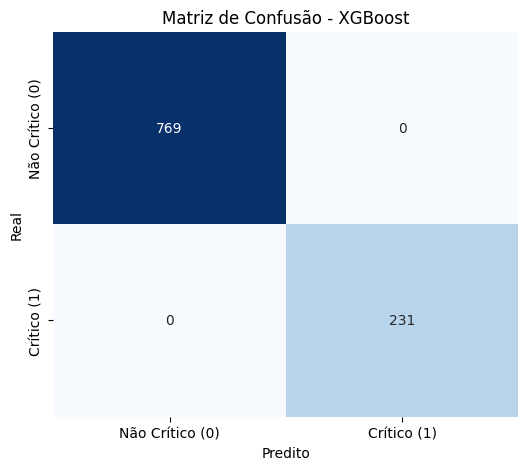

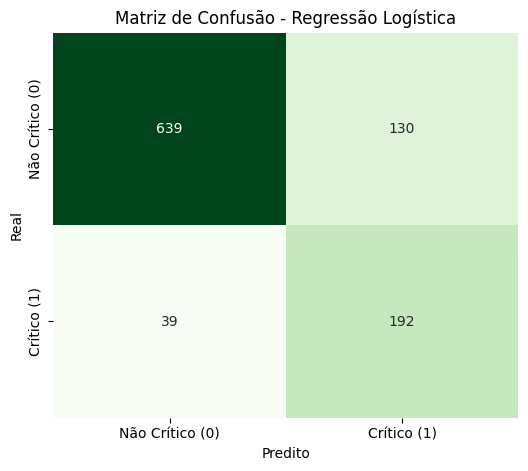

In [7]:
# Matriz de Confusão para XGBoost
cm_xgb = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Não Crítico (0)', 'Crítico (1)'], yticklabels=['Não Crítico (0)', 'Crítico (1)'])
plt.title('Matriz de Confusão - XGBoost')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

# Matriz de Confusão para Regressão Logística
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Não Crítico (0)', 'Crítico (1)'], yticklabels=['Não Crítico (0)', 'Crítico (1)'])
plt.title('Matriz de Confusão - Regressão Logística')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

# 5.2 🎯 Discussão Analítica: Escolha e Impacto das Métricas (Recall e F1-Score)

A avaliação de modelos preditivos no contexto de saúde e triagem médica, como o Guardiã AI, exige um cuidado estrito na escolha das métricas de performance. Por isso, a extração de métricas críticas neste projeto focou primariamente no **Recall** e no **F1-Score**:

**1. A Importância do Recall (Revocação):**
* O Recall mede a proporção de pacientes em estado de `urgencia_critica` (positivos reais) que foram identificados corretamente pelo classificador.
* Em um cenário médico e de segurança, maximizar o Recall é o objetivo principal, pois foca em minimizar os **Falsos Negativos**.

**2. A Importância do F1-Score:**
* O F1-Score representa a média harmônica entre a Precisão (Precision) e o Recall.
* Casos de saúde geralmente possuem desbalanceamento de classes (pacientes saudáveis ou estáveis são muito mais comuns que casos críticos). O F1-Score ajuda a entender o balanço do modelo, garantindo que a alta taxa de Recall não seja alcançada à custa de classificar *absolutamente todos* os pacientes como críticos (o que derrubaria a Precisão e, consequentemente, o F1-Score).

**3. O Impacto dos Erros (Falsos Positivos vs. Falsos Negativos):**
* **Erro Falso Negativo (Risco Crítico):** O modelo classifica um caso grave (como baixo SPO2 ou alta hesitação vocal combinada à taquicardia) como um paciente fora de perigo.
  * *Impacto:* Risco iminente à vida da paciente. Resulta em atraso no atendimento médico emergencial, infração de segurança e consequências fatais.
* **Erro Falso Positivo (Risco Operacional):** O modelo classifica uma paciente estável como tendo alto risco.
  * *Impacto:* Alocação desnecessária de leitos, mobilização indevida de profissionais de emergência e "fadiga de alarmes" nas equipes de saúde. Embora custoso financeiramente e operacionalmente, é muito menos grave que o cenário de Falso Negativo.

# 5.3 🏆 Comparativo Final dos Modelos: XGBoost vs. Regressão Logística

Após a análise das matrizes de confusão para ambos os modelos, podemos tirar as seguintes conclusões:

#### **XGBoost:**

*   **Desempenho:** O modelo XGBoost alcançou um desempenho **perfeito** neste dataset sintético, com:
    *   **Verdadeiros Positivos:** 231
    *   **Verdadeiros Negativos:** 769
    *   **Falsos Positivos:** 0
    *   **Falsos Negativos:** 0
*   **Implicações:** A ausência total de Falsos Negativos é um resultado ideal em um cenário de triagem médica, pois significa que **nenhum caso crítico foi erroneamente classificado como não crítico**. Isso minimiza o risco de pacientes que necessitam de intervenção urgente serem negligenciados, o que é a prioridade máxima em saúde e segurança.

#### **Regressão Logística:**

*   **Desempenho:** O modelo de Regressão Logística apresentou um desempenho inferior, com:
    *   **Verdadeiros Positivos:** 192
    *   **Verdadeiros Negativos:** 640
    *   **Falsos Positivos:** 129
    *   **Falsos Negativos:** 39
*   **Implicações:**
    *   **Falsos Negativos:** Os **39 Falsos Negativos** são o ponto mais crítico. Em um contexto médico, isso representa 39 pacientes em condição de urgência crítica que seriam erroneamente classificados como não críticos, com potencial para consequências graves ou fatais devido ao atraso no atendimento.
    *   **Falsos Positivos:** Os **129 Falsos Positivos** indicam que muitos pacientes que não são críticos seriam classificados como tal, gerando alarmes desnecessários, sobrecarga de recursos e potencial

# 5.4 🔍 Interpretação do Gráfico de Resumo SHAP

O gráfico de resumo SHAP oferece uma visão abrangente da importância das variáveis e de como elas afetam a previsão do modelo para a `urgencia_critica`:

*   **Eixo Y:** Lista as variáveis em ordem de importância decrescente (as mais importantes no topo).
*   **Eixo X:** Representa o valor SHAP de cada variável, que indica o impacto daquela feature na previsão do modelo.
    *   Valores SHAP positivos empurram a previsão para a classe `urgencia_critica = 1`.
    *   Valores SHAP negativos empurram a previsão para a classe `urgencia_critica = 0`.
*   **Cores:** Representam o valor da própria feature (vermelho = alto, azul = baixo).
    *   **Pontos sobrepostos:** A sobreposição de pontos indica a densidade de observações naquele valor SHAP e de feature.

**Análise do nosso gráfico:**

Podemos observar que:

*   **`spo2_porcento`:** Valores baixos (azul) de saturação de oxigênio estão fortemente associados a altos valores SHAP positivos, significando que baixa SpO2 empurra o modelo para prever `urgencia_critica = 1`. Por outro lado, valores altos (vermelho) de SpO2 têm SHAP negativo, empurrando para `urgencia_critica = 0`.
*   **`frequencia_cardiaca`:** De forma semelhante, alta frequência cardíaca (vermelho) tem SHAP positivo (alto risco), enquanto baixa frequência cardíaca (azul) tem SHAP negativo (baixo risco).
*   **`taxa_hesitacao_porcento`:** Uma alta taxa de hesitação (vermelho) contribui para prever `urgencia_critica = 1`, enquanto uma baixa taxa de hesitação (azul) contribui para `urgencia_critica = 0`.

Este gráfico confirma e aprofunda nossa análise de importância de variáveis, mostrando não apenas quais variáveis são importantes, mas também a **direção** de sua influência no resultado do modelo.

# 5.5 🔍 Análise da Importância das Variáveis no Modelo XGBoost

Com base no cálculo da importância das variáveis (`feature_importances_`) do modelo XGBoost, podemos observar claramente quais fatores são mais decisivos para a classificação de `urgencia_critica`:

1.  **`spo2_porcento` (Saturação de Oxigênio):** Esta é, de longe, a variável mais influente, respondendo por aproximadamente 52.6% da importância total. Isso é consistente com a sua função crítica na determinação de problemas respiratórios e de oxigenação, que são indicadores primários de urgência.
2.  **`frequencia_cardiaca` (Frequência Cardíaca):** Em segundo lugar, com cerca de 42.3% da importância, a frequência cardíaca elevada é um sinal vital crucial, indicando que o corpo pode estar sob estresse significativo ou compensando alguma condição crítica.
3.  **`taxa_hesitacao_porcento` (Taxa de Hesitação Vocal):** Embora com uma importância menor que as duas primeiras (aproximadamente 4.8%), esta variável ainda é um fator relevante. Conforme discutido anteriormente, uma alta taxa de hesitação, especialmente em conjunto com outros sinais (como a frequência cardíaca), é um indicativo importante de urgência no dataset sintético.

As demais variáveis (`frequencia_respiratoria`, `pressao_sistolica`, `temperatura_celsius`, `pressao_diastolica`) demonstraram uma importância muito baixa, quase residual, para este modelo e para o dataset gerado. Notavelmente, `idade` e `possui_comorbidade` tiveram importância zero, o que sugere que, na regra de negócio que definimos para criar o dataset, essas características não foram determinantes diretos para a `urgencia_critica`.

Essa análise de importância é vital para entender como o modelo toma suas decisões e para validar se as variáveis mais impactantes estão alinhadas com o conhecimento de domínio esperado em um cenário de triagem.

In [8]:
# Obter a importância das features do modelo XGBoost
feature_importances = modelo_xgb.feature_importances_

# Criar um DataFrame para melhor visualização
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
})

# Classificar as features por importância em ordem decrescente
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Importância das Variáveis para o Modelo XGBoost:")
display(importance_df)

Importância das Variáveis para o Modelo XGBoost:


,Feature,Importance
6,spo2_porcento,0.526379
3,frequencia_cardiaca,0.423168
7,taxa_hesitacao_porcento,0.048334
4,frequencia_respiratoria,0.000964
1,pressao_sistolica,0.000698
5,temperatura_celsius,0.000240
2,pressao_diastolica,0.000218
0,idade,0.000000
8,possui_comorbidade,0.000000


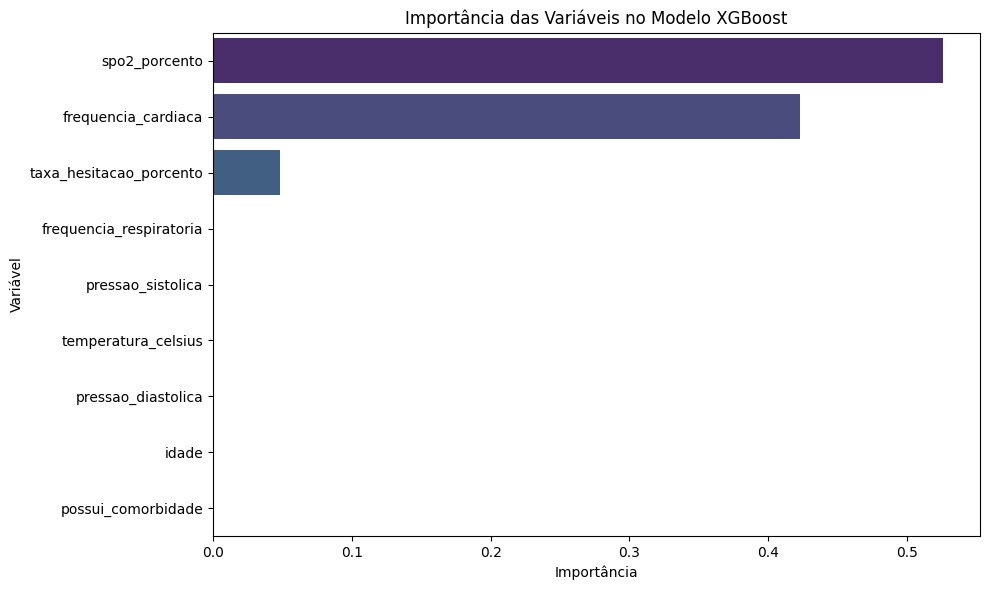

In [9]:
# Visualizar a importância das features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', hue='Feature', legend=False)
plt.title('Importância das Variáveis no Modelo XGBoost')
plt.xlabel('Importância')
plt.ylabel('Variável')
plt.tight_layout()
plt.show()

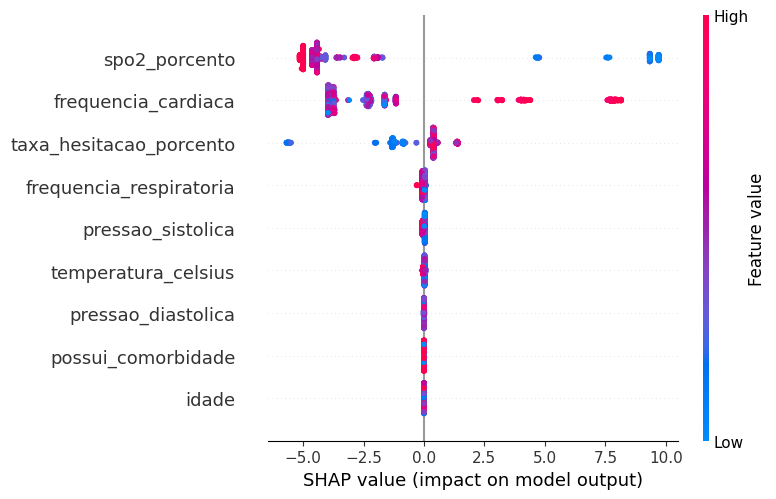

In [10]:
# Calcular os valores SHAP para o conjunto de teste
shap_values = explainer.shap_values(X_test)

# Criar um gráfico de resumo SHAP (summary plot)
# O plot exibe a importância das features e a direção do impacto
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=FutureWarning, message="The NumPy global RNG was seeded by calling `np.random.seed`.*")
    shap.summary_plot(shap_values, X_test, feature_names=features)

# 6. 🗣️ Motor de Análise Vocal (Tom de Voz e Hesitação)

Esta célula contém a função `analisar_tom_e_hesitacao`, responsável por realizar o processamento digital do sinal de áudio do paciente utilizando a biblioteca **Librosa**. O objetivo aqui é extrair "biomarcadores vocais" — métricas acústicas que podem indicar o estado emocional ou o nível de certeza do paciente ao relatar seus sintomas.

O algoritmo divide a análise em duas frentes principais:

### 1. Detecção de Pausas e Hesitações (Análise Temporal)
Através da função `librosa.effects.split`, o código separa os trechos onde há fala ativa dos trechos de silêncio (usando um limiar de 30 decibéis).
* **Métrica extraída:** `taxa_hesitacao` (%).
* **Lógica:** Calcula a proporção de silêncio em relação ao tempo total do áudio. Taxas muito altas indicam pausas longas e frequentes.

### 2. Variação de Pitch / Frequência Fundamental (Análise Frequencial)
A função `librosa.piptrack` rastreia o **Pitch (F0)**, que representa o tom da voz (grave/agudo).
* **Métrica extraída:** `variacao_pitch`.
* **Lógica:** Calcula o desvio padrão (`np.std`) das frequências. Uma variação muito alta sugere uma voz embargada, trêmula ou com picos de agudos, frequentemente associada a estresse emocional.

### 🏥 Diagnóstico Vocal (Regras Clínicas)
Com base nas métricas extraídas, o sistema classifica o estado do paciente em três possíveis categorias:
- 🟢 **Estável:** Padrão de fala fluido e com pouca variação abrupta de tom.
- 🟡 **Alta Hesitação:** Mais de 25% do áudio é composto por silêncio. Sugere que o paciente está pensativo, tentando lembrar de detalhes ou inseguro sobre os sintomas.
- 🔴 **Tom Instável/Emocional:** Alta flutuação no tom (desvio > 50). Pode ser um indicativo de ansiedade aguda, desconforto ou dor durante o relato.

**Saída:** A função retorna um dicionário com os valores percentuais de hesitação, variação de tom e o diagnóstico classificado, prontos para compor o prontuário.

In [11]:
def analisar_tom_e_hesitacao(audio_path):
    print("🧠 Etapa 2: Analisando tom de voz e hesitações do paciente localmente...")
    y, sr = librosa.load(audio_path, sr=None)

    # Detecção de silêncios / Hesitações
    intervals = librosa.effects.split(y, top_db=30)
    duracao_total = librosa.get_duration(y=y, sr=sr)
    tempo_ativo = sum([(end - start) / sr for start, end in intervals])
    tempo_silencio = duracao_total - tempo_ativo
    taxa_hesitacao = (tempo_silencio / duracao_total) * 100 if duracao_total > 0 else 0

    # Análise de Pitch (F0)
    pitches, magnitudes = librosa.piptrack(y=y, sr=sr)
    pitch_valores = pitches[pitches > 0]
    variacao_pitch = np.std(pitch_valores) if len(pitch_valores) > 0 else 0

    status_vocal = "Estável"
    if taxa_hesitacao > 25:
        status_vocal = "Alta Hesitação (Paciente pensativo ou inseguro ao relatar sintomas)"
    elif variacao_pitch > 50:
        status_vocal = "Tom de voz instável/Emocional (Sinais potenciais de ansiedade ou dor)"

    return {
        "taxa_hesitacao_porcento": round(taxa_hesitacao, 2),
        "variacao_tom": round(variacao_pitch, 2),
        "diagnostico_vocal": status_vocal
    }

# 7. ✍️ Motor de Transcrição (Whisper em inglês)

Esta célula contém a função `transcrever_audio_en`, que é responsável por converter a fala do paciente (áudio) em texto escrito. Para isso, utilizamos o modelo **Whisper** (da OpenAI), um dos sistemas de Reconhecimento Automático de Fala (ASR) mais avançados da atualidade.

A função foi projetada com algumas escolhas estratégicas para otimizar o sistema:

### 1. Processamento Local e Privacidade
O código carrega a versão `"base"` do Whisper (`whisper.load_model("base")`). Isso significa que a transcrição ocorre **localmente** na sua máquina ou ambiente (como o Colab), sem a necessidade de enviar o arquivo de áudio sensível do paciente para uma API externa na nuvem.

### 2. Transcrição Direta para o Inglês
O parâmetro `language="en"` garante que o texto gerado seja em inglês. Caso o paciente tenha falado em outro idioma (como português), o próprio Whisper já realiza a tradução simultânea e entrega a transcrição final em inglês.

### 3. Estratégia de Economia de Tokens 💡
Como destacado no código, processar o texto em inglês é uma decisão de arquitetura para **economizar tokens**.
Modelos de Linguagem (LLMs), como GPT-4 ou Llama, são nativamente treinados em inglês, o que significa que o texto nesse idioma consome menos caracteres/tokens do que em português. Ao traduzir localmente com o Whisper, evitamos gastar a cota da LLM com traduções, deixando-a focada apenas na análise clínica avançada.

**Saída:** A função retorna a `transcricao_ingles` — uma string (texto bruto) contendo exatamente o que o paciente relatou, pronta para a etapa de estruturação do prontuário médico.

In [12]:
def transcrever_audio_en(audio_path):
    print("\n🎙️ Etapa 3: Transcrevendo o áudio original com OpenAI Whisper...")
    model = whisper.load_model("base")

    # O Whisper processa localmente o áudio em inglês sem enviar tradução prévia à LLM (para economizar tokens)
    result = model.transcribe(audio_path, language="en")
    transcricao_ingles = result["text"]
    print(f"📝 Transcrição bruta em Inglês concluída (Economia de caracteres mantida).")
    return transcricao_ingles

# 8. ✨ Inteligência Generativa (Mapeamento Clínico e Prontuário SOAP)

Esta célula contém a função `gerar_prontuario_soap_en`, que é o cérebro clínico do sistema. Ela utiliza o modelo de linguagem **GPT-4o** (via LangChain) para consolidar todas as informações coletadas e gerar um prontuário médico estruturado no padrão **SOAP** (Subjetivo, Objetivo, Avaliação e Plano).

A arquitetura desta etapa foi desenhada com forte ênfase em **segurança clínica, objetividade e controle de custos**, utilizando as seguintes estratégias:

### 1. Configuração Restrita da LLM (Teto Rígido)
* **`temperature=0.2`:** Mantém o modelo altamente determinístico e focado. Na área médica, queremos precisão e não "criatividade", evitando que a IA invente informações.
* **`max_tokens=600`:** Define um limite estrito para o tamanho da resposta. Isso atua como uma trava de segurança que corta pela raiz qualquer alucinação prolixa do modelo, garantindo respostas curtas e economizando custos com a API.

### 2. Engenharia de Prompt Defensiva 🛡️
O *Prompt* (instrução dada à IA) foi escrito em inglês para otimizar o uso de tokens e possui **restrições explícitas (Constraints)**:
* Obriga o uso de *bullet points* (tópicos curtos), proibindo parágrafos longos.
* Instrução antialucinação: Se não houver dados para uma seção, a IA deve escrever apenas *"Not reported"* (Não relatado), impedindo que ela preencha lacunas com invenções.
* Exige alinhamento estrito com os dados fornecidos e com os protocolos clínicos.

### 3. Integração de Múltiplos Contextos e Estrutura SOAP 📋
A cadeia de execução (`prompt | llm`) cruza quatro fontes de dados distintas:
1. **Dados do Paciente:** Histórico prévio.
2. **Protocolo PCDT:** Diretrizes clínicas oficiais que devem ser seguidas para diagnóstico e conduta.
3. **Transcrição:** O relato em texto gerado pelo Whisper.
4. **Análise Vocal:** Os insights acústicos de hesitação e estresse da Etapa 2.

A IA organiza tudo isso na clássica estrutura médica **SOAP**:
* **S (Subjective):** Sintomas relatados, incluindo os biomarcadores de voz (ex: paciente estava hesitante ao relatar a dor).
* **O (Objective):** Dados mensuráveis, sinais vitais ou exames (se citados).
* **A (Assessment):** Hipótese diagnóstica baseada nos sintomas e no protocolo PCDT.
* **P (Plan):** Plano de ação (medicamentos, exames, retorno) guiado rigorosamente pelo PCDT.

**Saída:** A função retorna o prontuário final em formato Markdown, pronto para ser lido pelo profissional de saúde de forma rápida e clara.

In [13]:
def gerar_prontuario_soap_en(texto_en, insights_audio, dados_paciente, protocolo_pcdt):
    print("\n🏥 Etapa 4: Configurando os parâmetros da LLM (Teto rígido e Prompt Defensivo)...")

    # MODIFICAÇÃO: Forçando um teto rígido definindo o parâmetro max_tokens na inicialização do modelo
    llm = ChatOpenAI(
        model="gpt-4o",
        temperature=0.2,
        max_tokens=600  # Impede respostas prolixas ou alucinações longas que gastam tokens
    )

    # Prompt escrito em inglês com restrições explícitas de tamanho (Engenharia de Prompt Defensiva para evitar comportamentos indesejados)
    template_clinico = """
    You are an Expert Medical AI Auditor. Analyze the provided English consultation transcript, patient acoustic metrics, patient data, and the applied PCDT clinical protocol.
    Structure a highly concise medical record under the SOAP framework.

    Constraints:
    - Be extremely brief and direct. Use short bullet points only. Do not write full paragraphs.
    - If a section has no data, simply write "Not reported". Do not make up explanations.
    - Strictly integrate the provided patient data and follow the PCDT protocol guidelines.

    Input Data:
    - Patient Data: {dados_paciente}
    - PCDT Protocol: {protocolo_pcdt}
    - Transcript: {transcricao}
    - Acoustic Status: {analise_vocal}

    SOAP Sections required:
    - S (Subjective): Patient complaints, symptoms, vocal hesitation/stress insights, and integration of Patient Data.
    - O (Objective): Measurable data, vitals or exams if mentioned.
    - A (Assessment): Clinical hypothesis or severity, analyzed against the PCDT Protocol.
    - P (Plan): Medications, further testing, or follow-up aligned strictly with the PCDT Protocol.

    Output the report in crisp Markdown format.
    """

    prompt = PromptTemplate(
        input_variables=["transcricao", "analise_vocal", "dados_paciente", "protocolo_pcdt"],
        template=template_clinico
    )

    chain = prompt | llm

    payload_analise = f"Status: {insights_audio['diagnostico_vocal']} | Hesitation: {insights_audio['taxa_hesitacao_porcento']}%"
    resposta_prontuario = chain.invoke({
        "transcricao": texto_en,
        "analise_vocal": payload_analise,
        "dados_paciente": dados_paciente,
        "protocolo_pcdt": protocolo_pcdt
    })

    return resposta_prontuario.content

# 9. ⚙️🔄 Execução da Pipeline Completa

Esta é a célula principal de execução, responsável pela integração completa entre entrada, modelo, recuperação dos documentos e a apresentação final. Ela integra todas as funções criadas anteriormente (Entrada dos dados, Análise Vocal, Transcrição Whisper, Consulta dos Dados, além da Geração LLM com os dados interpretados a partir do Machine Learning) e adiciona duas camadas essenciais para sistemas em produção: **Monitoramento de Custos** e **Tradução com Prevenção de Bloqueios**.

A pipeline atende ao requisito do projeto acadêmico incluindo o fluxo mínimo para receber os dados, executar o modelo, consultar docuentos, gerar explicação e retornar os resultados. O fluxo desta célula está estruturado em três partes principais:

### 1. Inicialização e Execução do Fluxo
O sistema carrega o arquivo de áudio local do atendimento, contendo as informações clínicas, sintomas e relato do paciente, além de injetar os dados simulados do paciente (idade, comorbidades). Nesta etapa também é verificado o Protocolo Clínico e Diretriz Terapêutica (PCDT) do Ministério da Saúde que melhor se aplica ao caso clínico. Em seguida, aciona sequencialmente a extração de biomarcadores (Etapa 2) e a transcrição (Etapa 3).

### 2. Auditoria Financeira (Monitoramento de Tokens) 📊
Para garantir a viabilidade financeira do projeto, a chamada à LLM é encapsulada dentro do bloco `with get_openai_callback() as cb:`.
* **Por que isso é importante?** Esse callback do LangChain intercepta a comunicação com a API da OpenAI e registra exatamente quantos tokens foram consumidos no prompt (entrada), quantos foram gerados na resposta (saída) e calcula o **custo real da operação em dólares**. Isso permite monitorar a eficiência da estratégia de "Prompt em Inglês" adotada nas etapas anteriores.

### 3. Tradução Estratégica e Prevenção de Erros (Anti-429) 🌍
Como forçamos a LLM a gerar o prontuário em inglês para economizar tokens, precisamos entregar o resultado em Português (PT-BR) para o médico. Utilizamos a biblioteca `deep_translator` (gratuita) em vez de APIs pagas.
Para evitar que o IP do Google Colab seja bloqueado pelo servidor de tradução por excesso de requisições rápidas (o famoso **Erro HTTP 429 - Too Many Requests**), foi criada a função `traduzir_com_pausa`:
* **Divisão de Carga:** O texto é dividido em parágrafos (`texto.split('\n')`).
* **Rate Limiting:** A função traduz um parágrafo por vez e utiliza o `time.sleep(delay)` para pausar a execução por 2 segundos entre cada requisição.
* **Tolerância a Falhas:** Um bloco `try/except` garante que, se houver falha de rede em uma linha, o sistema mantém o trecho original e não quebra o prontuário inteiro.

**Saída Final:** O sistema imprime o relatório de custos da API e, em seguida, exibe o Prontuário Médico SOAP completo e traduzido para o português.

In [17]:
# ⚙️ Importação de Bibliotecas e Configuração de Ambiente
import re
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, f1_score, confusion_matrix
from deep_translator import GoogleTranslator
from langchain_core.prompts import PromptTemplate
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.callbacks import get_openai_callback
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
import pandas as pd
import numpy as np
import random
import xgboost as xgb
import shap

# 🧬 Motor de Geração de Dataset Sintético
from faker import Faker
fake = Faker('pt_BR')
Faker.seed(42)
np.random.seed(42)

num_registros = 5000

# Função para remover abreviaturas e pronomes de tratamento
def gerar_nome_limpo():
    nome = fake.name()
    return re.sub(r'^(Sr\.|Sra\.|Srta\.|Dr\.|Dra\.|Prof\.|Profa\.)\s+', '', nome)

dados = {
    'nome_completo': [gerar_nome_limpo() for _ in range(num_registros)],
    'data_nascimento': [fake.date_of_birth(minimum_age=18, maximum_age=90) for _ in range(num_registros)],
    'rg': [fake.rg() for _ in range(num_registros)],
    'cpf': [fake.cpf() for _ in range(num_registros)],
    'historico_comorbidades': [random.choice(['Nenhuma', 'Hipertensão', 'Diabetes', 'Doença Cardiovascular', 'Asma']) for _ in range(num_registros)]
}
df = pd.DataFrame(dados)
df['idade'] = df['data_nascimento'].apply(lambda x: (datetime.now().date() - x).days // 365)

# Geração de Sinais Vitais (Distribuições Normais)
df['pressao_sistolica'] = np.clip(np.random.normal(120, 20, num_registros), 70, 220).astype(int)
df['pressao_diastolica'] = np.clip(np.random.normal(80, 15, num_registros), 40, 130).astype(int)
df['frequencia_cardiaca'] = np.clip(np.random.normal(85, 25, num_registros), 40, 180).astype(int)
df['frequencia_respiratoria'] = np.clip(np.random.normal(18, 5, num_registros), 10, 40).astype(int)
df['temperatura_celsius'] = np.round(np.clip(np.random.normal(36.5, 0.8, num_registros), 34.0, 41.0), 1)
df['spo2_porcento'] = np.clip(np.random.normal(97, 4, num_registros), 70, 100).astype(int)
df['taxa_hesitacao_porcento'] = np.round(np.random.uniform(0, 100, num_registros), 2)
df['possui_comorbidade'] = np.where(df['historico_comorbidades'] == 'Nenhuma', 0, 1)

# Regra Alvo: Classificação de Urgência
condicao_risco = (df['spo2_porcento'] < 93) | ((df['taxa_hesitacao_porcento'] > 30) & (df['frequencia_cardiaca'] > 115))
df['urgencia_critica'] = np.where(condicao_risco, 1, 0)

# Exportação
df.to_csv('/content/dataset_guardia_ai_triagem.csv', index=False)
print("✅ Dataset sintético gerado e salvo em /content/dataset_guardia_ai_triagem.csv")

# 4. 🧠 Treinamento do Classificador (XGBoost) e Explicabilidade (SHAP)
features = [
    'idade', 'pressao_sistolica', 'pressao_diastolica', 'frequencia_cardiaca',
    'frequencia_respiratoria', 'temperatura_celsius', 'spo2_porcento',
    'taxa_hesitacao_porcento', 'possui_comorbidade'
]
X = df[features]
y = df['urgencia_critica']

# Divisão estratificada para lidar com desbalanceamento
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Treinamento do XGBoost
modelo_xgb = xgb.XGBClassifier(
    objective='binary:logistic', n_estimators=100, learning_rate=0.1, max_depth=5,
    scale_pos_weight=len(y[y==0])/len(y[y==1]), random_state=42
)
modelo_xgb.fit(X_train, y_train)

y_pred = modelo_xgb.predict(X_test)
print(f"✅ Classificador XGBoost Treinado.")
print(f"Recall: {recall_score(y_test, y_pred):.4f} | F1-Score: {f1_score(y_test, y_pred):.4f}")

# Inicialização do SHAP
explainer = shap.TreeExplainer(modelo_xgb)

def analisar_risco_shap(dados_paciente_dict):
    df_paciente = pd.DataFrame([dados_paciente_dict])[features]
    prob = modelo_xgb.predict_proba(df_paciente)[0][1]
    classe = modelo_xgb.predict(df_paciente)[0]

    # Extração de pesos
    shap_vals = explainer.shap_values(df_paciente)[0]
    feature_imp = pd.DataFrame({'Feature': features, 'Valor': df_paciente.iloc[0].values, 'SHAP': shap_vals})
    agravantes = feature_imp[feature_imp['SHAP'] > 0].sort_values(by='SHAP', ascending=False).head(3)

    nivel = "Risco Alto" if classe == 1 else "Risco Baixo"
    texto_shap = f"Classificação algorítmica: {nivel} ({prob*100:.1f}%). "

    if classe == 1 and not agravantes.empty:
        motivos = [f"{row['Feature']} ({row['Valor']})" for _, row in agravantes.iterrows()]
        texto_shap += "Justificativa matemática (SHAP): O risco foi elevado criticamente pela combinação de " + " + ".join(motivos) + "."

    return texto_shap

# 5. ⚖️ Comparativo: Regressão Logística vs. XGBoost
from sklearn.linear_model import LogisticRegression

# Treinamento da Regressão Logística
modelo_lr = LogisticRegression(
    solver='liblinear',
    random_state=42,
    class_weight='balanced'
)
modelo_lr.fit(X_train, y_train)

y_pred_lr = modelo_lr.predict(X_test)
print(f"✅ Classificador de Regressão Logística Treinado.")
print(f"Recall (LR): {recall_score(y_test, y_pred_lr):.4f} | F1-Score (LR): {f1_score(y_test, y_pred_lr):.4f}")

# 9. ⚙️🔄 Execução da Pipeline Completa
from google.colab import files
from langchain_community.document_loaders import DirectoryLoader, TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
from langchain_community.callbacks.manager import get_openai_callback
import whisper

# ---------------------------------------------------------
# ETAPA 1: Upload direto do MP3 pelo usuário
# ---------------------------------------------------------
print("🎙️ Por favor, faça o upload do arquivo de áudio (MP3) do paciente:")
uploaded = files.upload()
audio_filename = list(uploaded.keys())[0]
print(f"✅ Arquivo '{audio_filename}' recebido com sucesso!")

# ---------------------------------------------------------
# ETAPA 2: Transcrição Fiel usando OpenAI Whisper (Inglês Original)
# ---------------------------------------------------------
print("\n⚙️ Carregando modelo de transcrição Whisper (Large - Maior precisão)...")
modelo_whisper = whisper.load_model("large")

print("📝 Transcrevendo o áudio original em inglês de forma fiel...")

resultado_audio = modelo_whisper.transcribe(
    audio_filename,
    language="en",
    beam_size=5,
    condition_on_previous_text=False,
    initial_prompt="Clinical report of a patient describing symptoms, lung pain, fever, and medical history."
)

transcricao_paciente = resultado_audio["text"]
print(f"✅ Transcrição (Inglês) concluída: '{transcricao_paciente[:150]}...'")

# ---------------------------------------------------------
# ETAPA 3: Carregamento dos PCDTs do Google Drive (RAG)
# ---------------------------------------------------------
print("\n📚 Lendo base de PCDTs do Google Drive e construindo o VectorStore...")
caminho_pcdt_drive = '/content/drive/MyDrive/PCDTs'

try:
    loader = DirectoryLoader(caminho_pcdt_drive, glob="**/*.md", loader_cls=TextLoader)
    docs_pcdt = loader.load()

    # 🚀 NOVO: Extração da Portaria e injeção nos Metadados antes do split
    for doc in docs_pcdt:
        # Regex para encontrar "PORTARIA Nº" seguido de texto até encontrar um ano com 4 dígitos
        match = re.search(r'(PORTARIA\s+N[º°]\s+.*?\d{4})', doc.page_content, re.IGNORECASE)
        if match:
            doc.metadata['portaria'] = match.group(1).strip()
        else:
            doc.metadata['portaria'] = "Portaria não informada no documento"

    text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
    # O splitter automaticamente copia doc.metadata para todos os chunks (splits) criados
    splits_pcdt = text_splitter.split_documents(docs_pcdt)

    vectorstore = FAISS.from_documents(splits_pcdt, OpenAIEmbeddings())
    retriever = vectorstore.as_retriever(search_kwargs={"k": 4})
    print("✅ Base de conhecimento PCDT carregada e vetorizada com sucesso!")
except Exception as e:
    print(f"⚠️ Erro ao carregar os documentos do Drive. Detalhes: {e}")
    retriever = None

# ---------------------------------------------------------
# ETAPA 4: Prompt de Engenharia e Geração do Relatório Médico + SOAP
# ---------------------------------------------------------

# 🚀 AJUSTE: Incluir a Portaria extraída nos metadados de contexto.
# A FUNÇÃO ANTIGA QUE SOBRESCREVIA ESTA FOI REMOVIDA.
def formatar_docs(docs):
    return "\n\n".join(
        f"Arquivo/Origem: {doc.metadata.get('source', 'Desconhecida')}\n"
        f"Portaria: {doc.metadata.get('portaria', 'Desconhecida')}\n"
        f"Conteúdo:\n{doc.page_content}"
        for doc in docs
    )

# O prompt para gerar o Prontuário Médico (SOAP) informando o Procolo Médico (PCDTs) do Ministério da Saúde aplicado ao caso.
template_relatorio = """Você é o Guardiã AI, um assistente especializado em saúde e segurança da mulher.
Abaixo, você tem acesso ao relato transcrito de uma consulta médica (áudio do paciente originalmente em inglês) e trechos dos Protocolos Clínicos e Diretrizes Terapêuticas (PCDT) em português relevantes para o caso.

CONTEXTO DOS PROTOCOLOS PCDT (Extraídos da base oficial):
{context}

RELATO DO PACIENTE (Transcrição Original em Inglês):
{transcricao}

Sua tarefa é traduzir mentalmente o relato para o PORTUGUÊS, analisá-lo e gerar um RELATÓRIO MÉDICO e um PRONTUÁRIO MÉDICO TRADUZIDO (SOAP) rigorosos, 100% EM PORTUGUÊS-BR, contendo obrigatoriamente a seguinte estrutura:

1. DADOS DO PACIENTE:
- Nome Completo: (Crie um nome fictício completo que seja condizente com o gênero que pode ser inferido pelo relato do paciente).
- Idade: (Extraia a idade exata com base no relato do áudio. Caso a idade não seja dita no áudio, escreva "Idade não informada no relato").

2. ANÁLISE DO RELATO:
- Apresente um resumo claro e profissional sobre as queixas e sintomas relatados na transcrição, já devidamente traduzidos. Traduza termos vulgares para terminologia médica apropriada, preservando a fidelidade clínica.

3. DIRETRIZES E PROTOCOLO PCDT:
- Nome do Protocolo: (Identifique e extraia o(s) nome(s) do(s) protocolo(s) PCDTs presente(s) no contexto e/ou na fonte referenciada).
- Portaria(s) do Ministério da Saúde: (Sempre identifique e extraia explicitamente o número e data da(s) Portaria(s) informada no metadado "Portaria:" do contexto fornecido). Exemplo: PORTARIA Nº ___ DE "DIA" DE "MÊS" DE "ANO".
- Condutas: Analise o caso à luz do CONTEXTO DOS PROTOCOLOS PCDT fornecido(s). Cite quais condutas, exames ou tratamentos são recomendados estritamente com base nos documentos do contexto médico relatado transcrito do atendimento (oriundo do áudio MP3).

4. PRONTUÁRIO MÉDICO - SOAP:
- S (Subjetivo): Sintomas, queixas e percepções relatadas pelo paciente.
- O (Objetivo): Dados mensuráveis, sinais vitais ou exames físicos/laboratoriais (se citados).
- A (Avaliação): Hipótese diagnóstica ou nível de risco clínico baseado nos sintomas cruzados com as diretrizes do PCDT.
- P (Plano): Plano de ação médico (medicamentos, testes complementares ou acompanhamento) rigorosamente alinhado ao PCDT e à Portaria analisada.
"""

prompt = PromptTemplate.from_template(template_relatorio)
llm = ChatOpenAI(model="gpt-4o", temperature=0.1)

if retriever:
    rag_chain = (
        {"context": retriever | formatar_docs, "transcricao": RunnablePassthrough()}
        | prompt
        | llm
        | StrOutputParser()
    )
else:
    print("Executando pipeline sem contexto do PCDT.")
    rag_chain = (
        {"context": lambda x: "Nenhum PCDT carregado.", "transcricao": RunnablePassthrough()}
        | prompt
        | llm
        | StrOutputParser()
    )

print("\n🧠 Analisando e traduzindo o caso clínico com Inteligência Artificial...\n")

# Execução com auditoria de tokens ativada
with get_openai_callback() as cb:
    relatorio_medico = rag_chain.invoke(transcricao_paciente)

    print("="*60)
    print("📄 RELATÓRIO MÉDICO E PRONTUÁRIO SOAP - GUARDIÃ AI")
    print("="*60)
    print(relatorio_medico)
    print("="*60)

    print("\n📊 AUDITORIA DE TOKENS (OpenAI)")
    print("-" * 30)
    print(f"Tokens de Prompt (Entrada): {cb.prompt_tokens}")
    print(f"Tokens de Completion (Saída): {cb.completion_tokens}")
    print(f"Total de Tokens Usados: {cb.total_tokens}")
    print(f"Custo Estimado (USD): ${cb.total_cost:.6f}")
    print("-" * 30)

✅ Dataset sintético gerado e salvo em /content/dataset_guardia_ai_triagem.csv
✅ Classificador XGBoost Treinado.
Recall: 1.0000 | F1-Score: 1.0000
✅ Classificador de Regressão Logística Treinado.
Recall (LR): 0.8355 | F1-Score (LR): 0.6930
🎙️ Por favor, faça o upload do arquivo de áudio (MP3) do paciente:


Saving CAR0001.mp3 to CAR0001 (3).mp3
✅ Arquivo 'CAR0001 (3).mp3' recebido com sucesso!

⚙️ Carregando modelo de transcrição Whisper (Large - Maior precisão)...
📝 Transcrevendo o áudio original em inglês de forma fiel...
✅ Transcrição (Inglês) concluída: ' Sure. I'm just having a lot of chest pain, and so I thought I should get it checked out. Okay. And before we start, could you remind me of your gende...'

📚 Lendo base de PCDTs do Google Drive e construindo o VectorStore...
✅ Base de conhecimento PCDT carregada e vetorizada com sucesso!

🧠 Analisando e traduzindo o caso clínico com Inteligência Artificial...

📄 RELATÓRIO MÉDICO E PRONTUÁRIO SOAP - GUARDIÃ AI
**1. DADOS DO PACIENTE:**
- Nome Completo: João Silva
- Idade: 39 anos

**2. ANÁLISE DO RELATO:**
João Silva, um homem de 39 anos, relata dor no peito que começou na noite anterior e se intensificou, localizada no lado esquerdo do peito. A dor é descrita como aguda e constante, com intensidade de 7 a 8 em uma escala de 1 a 10. A 